Parte 1

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_excel(
    'Tabela_13_Meio_de_transporte.xlsx',
    sheet_name='Exemplo gráfico Brasil',
    header=1
)
df.columns = ['Meio de Transporte', 'Branca', 'Preta ou Parda', 'Indígena']
df


                Meio de Transporte  Branca  Preta ou Parda  Indígena
0                             A pé    19.4            24.8      37.5
1                        Bicicleta     3.2             5.2       5.9
2          Motocicleta ou Mototaxi     9.9            14.2      15.4
3  Automóvel, taxi ou assemelhados    41.8            20.6      15.2
4              Transporte coletivo    25.2            34.6      22.4
5                           Outros     0.5             0.6       3.6

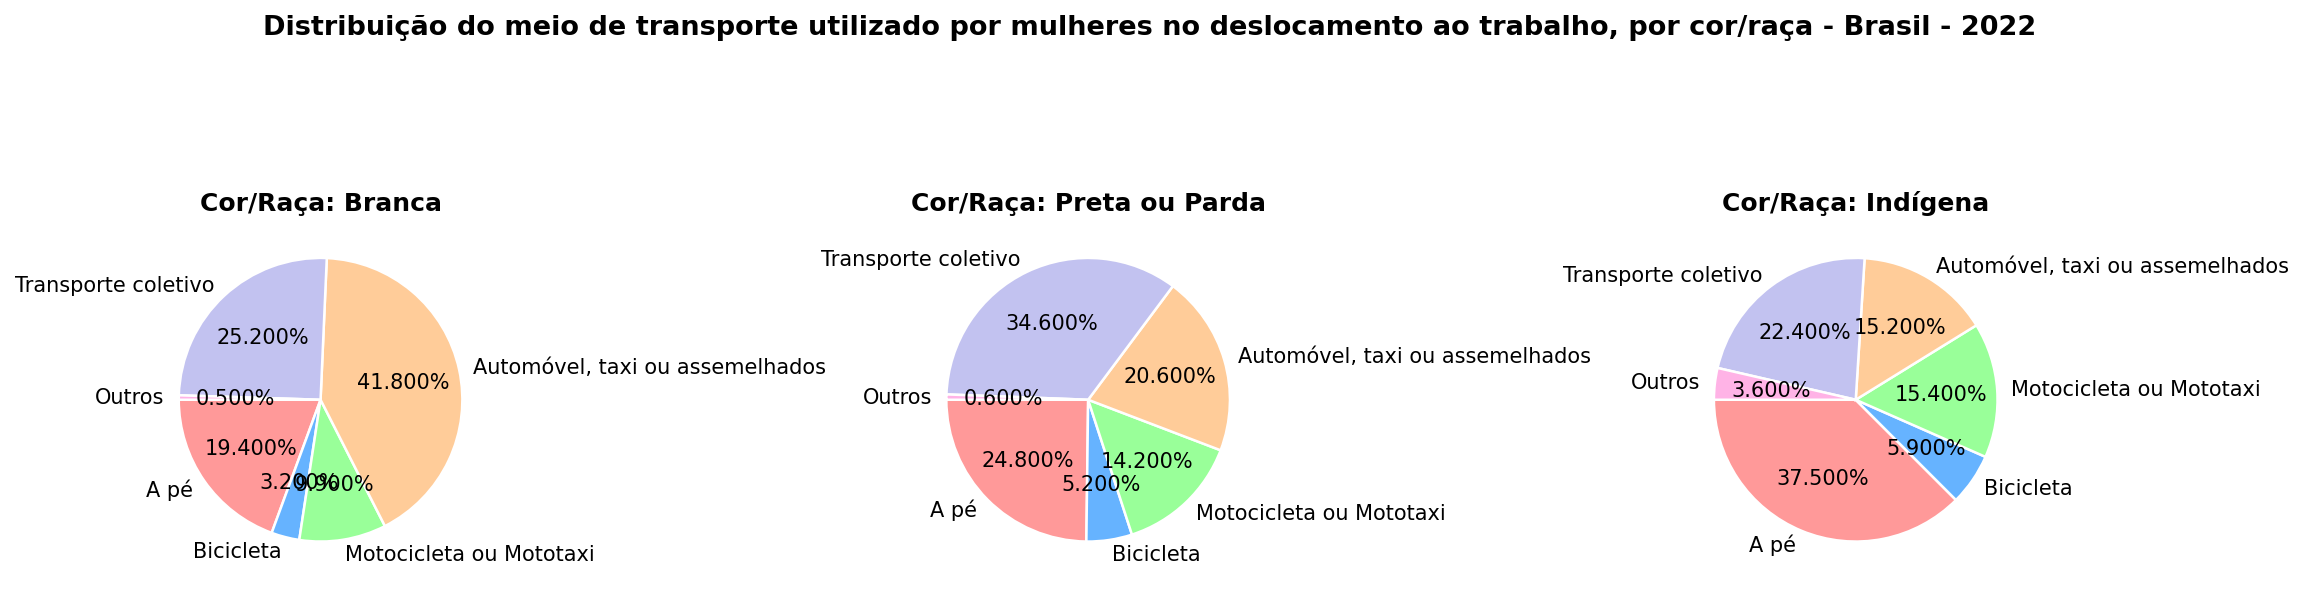

In [3]:
TAMANHO = (15, 5)
fig, axes = plt.subplots(1, 3, figsize=TAMANHO)
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',  
        startangle=180,      
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Distribuição do meio de transporte utilizado por mulheres no deslocamento ao trabalho, por cor/raça - Brasil - 2022',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()


## Análise dos gráficos — diferenças por meio de transporte e cor/raça

Comparando os três gráficos, dá pra ver que o meio de transporte muda bastante conforme a cor/raça da mulher. As diferenças (em pontos percentuais) entre os grupos, para cada modo, são:

**A pé**
- Brancas − Pretas ou Pardas: -5.4 pp (Brancas andam menos a pé)
- Brancas − Indígenas: -18,1 pp
- Pretas/Pardas − Indígenas: -12,7 pp
- Mulheres indígenas se deslocam a pé muito mais (37,5%) que as demais — quase o dobro das pretas/pardas e quase o triplo das brancas.

**Bicicleta**
- Brancas − Pretas/Pardas: -2,0 pp
- Brancas − Indígenas: -2,7 pp
- Uso baixo nos três grupos, mas indígenas (5,9%) e pretas/pardas (5,2%) usam um pouco mais bicicleta que as brancas (3,2%).

**Motocicleta ou Mototáxi**
- Brancas − Pretas/Pardas: -4,3 pp
- Brancas − Indígenas: -5,5 pp
- Pretas/pardas (14,2%) e indígenas (15,4%) usam bem mais moto/mototáxi que as brancas (9,9%).

**Automóvel, táxi ou assemelhados (o modo com maior diferença)**
- **Brancas − Pretas/Pardas: 21,2 pp** (41,8% vs 20,6%)
- **Brancas − Indígenas: 26,6 pp** (41,8% vs 15,2%)
- Pretas/Pardas − Indígenas: 5,4 pp
- Esse é o meio de transporte com a maior disparidade: mulheres brancas usam carro/táxi mais que o dobro das mulheres pretas/pardas e quase o triplo das indígenas.

**Transporte coletivo**
- Brancas − Pretas/Pardas: -9,4 pp (25,2% vs 34,6%)
- Brancas − Indígenas: 2,8 pp
- Pretas/Pardas − Indígenas: 12,2 pp
- Mulheres pretas/pardas são as que mais dependem de transporte coletivo (34,6%), bem acima das brancas (25,2%) e das indígenas (22,4%).

**Outros**
- Diferenças pequenas entre brancas e pretas/pardas (-0,1 pp), mas indígenas usam bem mais "outros" meios (3,6% vs ~0,5-0,6%).

### Resumo
- **Mulheres brancas** concentram o uso de **automóvel/táxi** (41,8%), meio de transporte individual e de maior custo.
- **Mulheres pretas/pardas** dependem mais de **transporte coletivo** (34,6%) e de **moto/mototáxi**.
- **Mulheres indígenas** se deslocam majoritariamente **a pé** (37,5%), o que sugere menor acesso a transporte motorizado, público ou privado.
- Isso mostra que o acesso a transporte de melhor qualidade/conforto (carro próprio) ainda está fortemente associado à cor/raça no Brasil.


---
# Parte 2 

In [3]:

raw = pd.read_excel(
    'Tabela_13_Meio_de_transporte.xlsx',
    sheet_name='BR GR UF MU',
    header=None
)


modos = ['A pé', 'Bicicleta', 'Motocicleta ou Mototaxi',
         'Automóvel, taxi ou assemelhados', 'Transporte coletivo', 'Outros']
racas = ['Branca', 'Preta ou Parda', 'Indígena']

cols = ['Local']
for r in racas:
    for m in modos:
        cols.append(f'{m} - {r}')

data = raw.iloc[3:].copy()          
data.columns = cols
data = data.reset_index(drop=True)

for c in cols[1:]:
    data[c] = pd.to_numeric(data[c], errors='coerce')

data.head()


NameError: name 'pd' is not defined

In [ ]:
estados = data.iloc[6:33].copy().reset_index(drop=True)      
municipios = data.iloc[33:].copy().reset_index(drop=True)     
municipios['Local'] = municipios['Local'].astype(str)

print(f"Total de estados: {len(estados)}")
estados['Local']


Total de estados: 27
           Rondônia
               Acre
           Amazonas
            Roraima
               Pará
              Amapá
          Tocantins
           Maranhão
              Piauí
              Ceará
Rio Grande do Norte
            Paraíba
         Pernambuco
            Alagoas
            Sergipe
              Bahia
       Minas Gerais
     Espírito Santo
     Rio de Janeiro
          São Paulo
             Paraná
     Santa Catarina
  Rio Grande do Sul
 Mato Grosso do Sul
        Mato Grosso
              Goiás
   Distrito Federal

### 3 - Respondendo às questões

> **Observação:** a planilha só traz os percentuais de uso de cada transporte **separados por cor/raça** (Branca, Preta ou Parda, Indígena) — não existe uma coluna de total "geral". Para responder "em geral", foi calculada a **média simples entre os três grupos de cor/raça** em cada linha, como uma aproximação do valor geral.

In [ ]:
# Qual estado tem mais e qual tem menos mulheres, em geral, usando transporte coletivo?

tc_cols = [f'Transporte coletivo - {r}' for r in racas]
estados['Transporte coletivo (média geral)'] = estados[tc_cols].mean(axis=1).round(2)

tabela_tc = estados[['Local', 'Transporte coletivo (média geral)']] \
    .sort_values('Transporte coletivo (média geral)', ascending=False) \
    .reset_index(drop=True)

print(tabela_tc.to_string(index=False))

mais = estados.loc[estados['Transporte coletivo (média geral)'].idxmax()]
menos = estados.loc[estados['Transporte coletivo (média geral)'].idxmin()]

print(f"\nEstado com MAIS mulheres usando transporte coletivo: {mais['Local']} ({mais['Transporte coletivo (média geral)']:.2f}%)")
print(f"Estado com MENOS mulheres usando transporte coletivo: {menos['Local']} ({menos['Transporte coletivo (média geral)']:.2f}%)")


              Local  Transporte coletivo (média geral)
     Rio de Janeiro                              52.23
   Distrito Federal                              46.00
          São Paulo                              40.73
  Rio Grande do Sul                              36.10
            Sergipe                              33.40
     Espírito Santo                              32.63
             Paraná                              27.57
       Minas Gerais                              27.10
              Goiás                              25.10
         Pernambuco                              25.03
           Amazonas                              24.03
     Santa Catarina                              23.77
Rio Grande do Norte                              23.73
              Ceará                              23.40
              Bahia                              23.10
            Alagoas                              22.37
               Pará                              20.63
          

In [ ]:
# Qual cidade do Brasil tem mais mulheres andando de bicicleta?

bici_cols = [f'Bicicleta - {r}' for r in racas]
municipios['Bicicleta (média geral)'] = municipios[bici_cols].mean(axis=1).round(2)

top_bici = municipios.sort_values('Bicicleta (média geral)', ascending=False).head(10).reset_index(drop=True)
print(top_bici[['Local', 'Bicicleta (média geral)']].to_string(index=False))

print(f"\nCidade com mais mulheres de bicicleta: {top_bici.iloc[0]['Local']} ({top_bici.iloc[0]['Bicicleta (média geral)']:.2f}%)")


                      Local  Bicicleta (média geral)
                Tuiuti (SP)                   100.00
                  Afuá (PA)                    72.05
    Novo Santo Antônio (MT)                    68.90
          Lagoa Grande (MG)                    67.87
              Britânia (GO)                    64.47
Bom Jesus do Tocantins (TO)                    64.37
           Tumiritinga (MG)                    63.87
             Cocalinho (MT)                    59.27
             Riachinho (MG)                    59.05
      Morrinhos do Sul (RS)                    59.05

Cidade com mais mulheres de bicicleta: Tuiuti (SP) (100.00%)

In [ ]:
# Qual cidade do Brasil tem mais mulheres utilizando carro?

auto_cols = [f'Automóvel, taxi ou assemelhados - {r}' for r in racas]
municipios['Automóvel (média geral)'] = municipios[auto_cols].mean(axis=1).round(2)

top_auto = municipios.sort_values('Automóvel (média geral)', ascending=False).head(10).reset_index(drop=True)
print(top_auto[['Local', 'Automóvel (média geral)']].to_string(index=False))

print(f"\nCidade com mais mulheres de carro: {top_auto.iloc[0]['Local']} ({top_auto.iloc[0]['Automóvel (média geral)']:.2f}%)")


                  Local  Automóvel (média geral)
Bom Jesus do Oeste (SC)                    86.05
         Bom Jesus (SC)                    74.57
    Tupanci do Sul (RS)                    74.55
          Valinhos (SP)                    71.43
       Piratininga (SP)                    71.40
             Ibiam (SC)                    70.35
            Bozano (RS)                    69.40
     Coronel Pilar (RS)                    68.80
       Nova Odessa (SP)                    68.57
    Pinheiro Preto (SC)                    68.43

Cidade com mais mulheres de carro: Bom Jesus do Oeste (SC) (86.05%)

### Resumo das respostas

| Pergunta | Resposta |
|---|---|
| Estado com **mais** mulheres usando transporte coletivo (em geral) | **Rio de Janeiro (52.23%)** |
| Estado com **menos** mulheres usando transporte coletivo (em geral) | **Rondônia (4.33%)** |
| Cidade com **mais** mulheres andando de **bicicleta** | **Tuiuti (SP) (100.00%)** |
| Cidade com **mais** mulheres usando **carro** | **Bom Jesus do Oeste (SC) (86.05%)** |

**Observações importantes:**
- O Rio de Janeiro lidera de forma isolada o uso de transporte coletivo, refletindo sua alta densidade urbana e a extensão do sistema de trens/metrô/ônibus; o Distrito Federal e São Paulo vêm em seguida.
- Rondônia, Roraima e Tocantins têm o menor uso de transporte coletivo — estados do Norte com cidades menores e menos infraestrutura de transporte público, onde moto e carro/a pé predominam.
- No caso de bicicleta e carro, os primeiros lugares são **municípios pequenos**. Percentuais de 100% (como Tuiuti-SP) provavelmente refletem **amostras muito pequenas** da pesquisa (poucas mulheres entrevistadas naquele município), então esses extremos devem ser interpretados com cautela — não necessariamente indicam uma "cultura" consolidada de uso de bicicleta ou carro, mas sim o tamanho reduzido da amostra na base de dados.
